# Лабораторная работа 2
## Гистограммная эквализация изображения

**Цель:** самостоятельно реализовать гистограммную эквализацию полутонового изображения средствами NumPy.

Эквализация перераспределяет значения яркости по накопленной гистограмме, чтобы задействовать более широкий диапазон оттенков и повысить различимость деталей.

In [1]:
def histogram_equalization(image: 'np.ndarray') -> 'np.ndarray':
    """Выполняет гистограммную эквализацию 8-битного полутонового изображения."""
    if image.ndim != 2:
        raise ValueError('Ожидается двумерное полутоновое изображение.')

    gray = image.astype(np.uint8, copy=False)
    histogram = np.bincount(gray.ravel(), minlength=256)
    cdf = histogram.cumsum()
    nonzero_cdf = cdf[cdf > 0]

    if nonzero_cdf.size == 0 or nonzero_cdf[0] == gray.size:
        return gray.copy()

    lut = np.round((cdf - nonzero_cdf[0]) * 255 / (gray.size - nonzero_cdf[0]))
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[gray]

## Самостоятельная реализация

Алгоритм строит гистограмму из 256 уровней яркости, вычисляет её накопленную сумму и формирует таблицу замены яркостей (LUT). Для изображения с единственным уровнем яркости функция возвращает копию: контраст в таком изображении увеличить невозможно.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)

## Обработка изображения

Для демонстрации используется изображение `lenna.png` из материалов ко второй лабораторной. Цветное изображение переводится в оттенки серого по стандартной взвешенной формуле яркости.

In [4]:
image_path = Path.cwd().parent / 'metod' / 'Лабораторная2' / 'lenna.png'
if not image_path.exists():
    image_path = Path('metod/Лабораторная2/lenna.png')

rgb_image = plt.imread(image_path)
if rgb_image.dtype.kind == 'f':
    rgb_image = np.round(rgb_image * 255).astype(np.uint8)

gray_image = np.round(0.299 * rgb_image[..., 0] + 0.587 * rgb_image[..., 1] + 0.114 * rgb_image[..., 2]).astype(np.uint8)
equalized_image = histogram_equalization(gray_image)
print(f'Размер изображения: {gray_image.shape}; диапазон до обработки: {gray_image.min()}..{gray_image.max()}')
print(f'Диапазон после обработки: {equalized_image.min()}..{equalized_image.max()}')

Размер изображения: (512, 512); диапазон до обработки: 25..245
Диапазон после обработки: 0..255


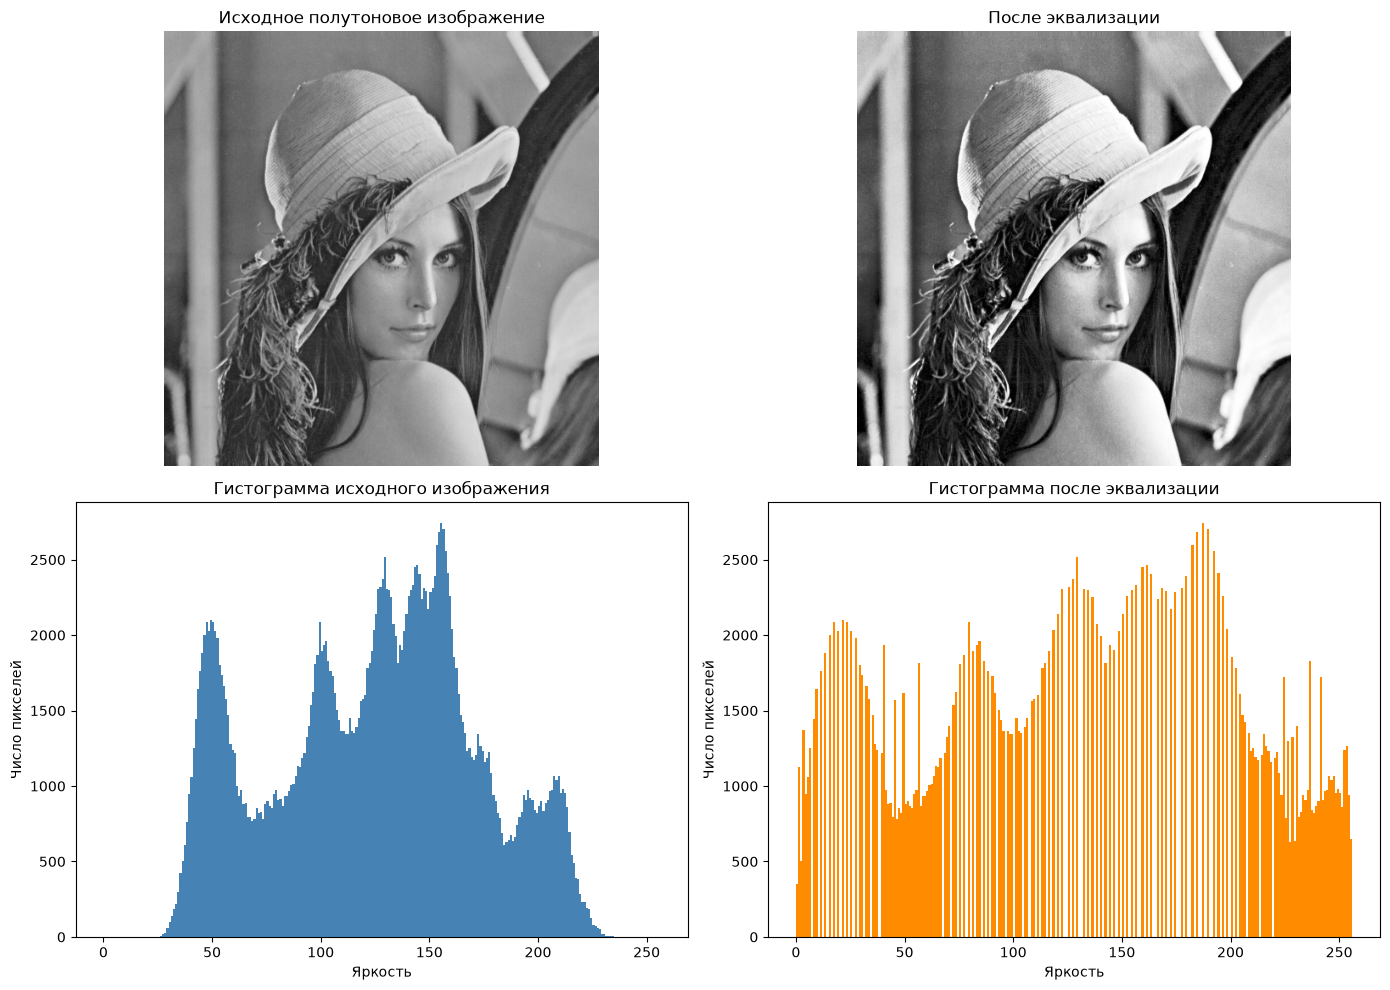

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(gray_image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Исходное полутоновое изображение')
axes[0, 1].imshow(equalized_image, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('После эквализации')
axes[1, 0].hist(gray_image.ravel(), bins=256, range=(0, 256), color='steelblue')
axes[1, 0].set_title('Гистограмма исходного изображения')
axes[1, 1].hist(equalized_image.ravel(), bins=256, range=(0, 256), color='darkorange')
axes[1, 1].set_title('Гистограмма после эквализации')
for axis in axes[0]:
    axis.axis('off')
for axis in axes[1]:
    axis.set_xlabel('Яркость')
    axis.set_ylabel('Число пикселей')
plt.tight_layout()
plt.show()

## Вывод

Самостоятельная реализация перераспределила яркости на основе накопленной гистограммы. Гистограмма результата использует диапазон яркостей более равномерно, поэтому детали в тёмных и светлых областях становятся заметнее.